In [ ]:
# Set LOAD_FROM_SAVED before running the notebook
# True means load saved files and skip training
# False means train everything from scratch

LOAD_FROM_SAVED = True

# Extract ZIP from Google Drive
# Only runs if LOAD_FROM_SAVED is True and we are on Colab

import os

if LOAD_FROM_SAVED:
    # zip_path = "/content/drive/MyDrive/all_outputs.zip"
    # try:
    #     from google.colab import drive
    #     drive.mount('/content/drive')

    #     if os.path.exists(zip_path):
    #         import zipfile
    #         with zipfile.ZipFile(zip_path, "r") as zf:
    #             zf.extractall(".")
    #             print(f"Extracted {len(zf.namelist())} files from {zip_path}")
    #         print("Files ready. Run all cells, training will be skipped.")
    #     else:
    #         print(f"{zip_path} not found. If pkl files are already in saved_models, continue.")
    # except ImportError:
    #     print("Not running on Colab, skipping Drive mount.")
    pass
else:
    print("LOAD_FROM_SAVED is False, skipping Drive extraction. Models will be trained from scratch.")

Mounted at /content/drive
✓ Extracted 78 files from /content/drive/MyDrive/all_outputs.zip
✓ Files ready. Now just Run All — training cells are skipped automatically.


# Q2.1 - Classical Baseline vs Fine-tuned Transformer for Sentiment and Sarcasm

- **Data:** All three varieties (en-AU, en-IN, en-UK) combined into one train/val/test split.
- **Classical:** TF-IDF (unigram + bigram) with Logistic Regression and Linear SVM, using class_weight='balanced'
- **FastText:** Supervised classifier with autotuned hyperparameters and minority class oversampling
- **Transformer:** roberta-base fine-tuned with weighted cross-entropy
- **Seeds:** 3 runs per setup (42, 123, 456), reporting mean and std
- **Metrics:** Macro-F1 (main one), Precision, Recall, per-class results, confusion matrices

## 1. Setup & Installations

In [2]:
# Install required packages (run once)
%pip install datasets transformers accelerate scikit-learn matplotlib seaborn pandas numpy -q

In [3]:
import os
import random
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from collections import Counter

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

import torch
from torch.utils.data import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")

SEEDS = [42, 123, 456]  # three seeds for multiple runs
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "./saved_models"  # where to save trained models and results
os.makedirs(SAVE_DIR, exist_ok=True)

# Q2.2 stuff, kept here so it works after loading saved models
VARIETIES = ["en-AU", "en-IN", "en-UK"]
CROSS_SEEDS = [42, 123]  # two seeds for cross-variety runs
CROSS_TASK = "Sentiment"

print(f"Using device: {DEVICE}")
print(f"Models will be saved to: {SAVE_DIR}")

Using device: cuda
Models will be saved to: ./saved_models


In [4]:
def set_seed(seed: int):
    """Set the random seed so results are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 2. Data Loading & Exploration

We load all three varieties from the BESSTIE dataset and **pool** them into unified splits. The pre-defined train/validation/test splits are respected - we never leak data across them.

In [5]:
# Load the dataset (one config, variety is just a column)
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)
print(f"\nColumns: {ds['train'].column_names}")
print(f"\nSample row:\n{ds['train'][0]}")

# Check how many examples per variety
for split in ["train", "validation", "test"]:
    varieties = Counter(ds[split]["variety"])
    print(f"\n{split}: {dict(varieties)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})

Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']

Sample row:
{'text': "I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.", 'variety': 'en-UK', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 0.0}

train: {'en-UK': 1203, 'en-AU': 1145, 'en-IN': 1399}

validation: {'en-AU': 95, 'en-IN': 117, 'en-UK': 101}

test: {'en-AU': 667, 'en-UK': 700, 'en-IN': 816}


In [6]:
# Dataset already has all varieties pooled in each split, so just use it as is
pooled = ds

print("Dataset sizes (all varieties together):")
for split in ["train", "validation", "test"]:
    print(f"  {split}: {len(pooled[split])} samples")

Dataset sizes (all varieties pooled):
  train: 3747 samples
  validation: 313 samples
  test: 2183 samples


In [7]:
# Column names from the dataset card
text_col = "text"
sentiment_col = "Sentiment"
sarcasm_col = "Sarcasm"

print(f"Text column: {text_col}")
print(f"Sentiment column: {sentiment_col}")
print(f"Sarcasm column: {sarcasm_col}")

Text column    : text
Sentiment column: Sentiment
Sarcasm column  : Sarcasm


In [8]:
# Check class distribution for each task
for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    print(f"\n{task_name} ({label_col})")
    for split in ["train", "validation", "test"]:
        labels = pooled[split][label_col]
        counts = Counter(labels)
        total = len(labels)
        print(f"  {split:>10}: {dict(counts)}  (total={total}, "
              f"minority ratio={min(counts.values())/total:.2%})")


=== Sentiment (Sentiment) ===
       train: {0.0: 1907, 1.0: 1840}  (total=3747, minority ratio=49.11%)
  validation: {1.0: 153, 0.0: 160}  (total=313, minority ratio=48.88%)
        test: {1.0: 1066, 0.0: 1117}  (total=2183, minority ratio=48.83%)

=== Sarcasm (Sarcasm) ===
       train: {0.0: 3223, 1.0: 524}  (total=3747, minority ratio=13.98%)
  validation: {0.0: 269, 1.0: 44}  (total=313, minority ratio=14.06%)
        test: {0.0: 1878, 1.0: 305}  (total=2183, minority ratio=13.97%)


## Load Saved Results (Skip Training)

`LOAD_FROM_SAVED` is set in **Cell 1** at the very top of the notebook. When `True` (the default), the cell below loads all pre-computed results from `.pkl` files and **all training cells are automatically skipped** - just **Run All**.

To retrain from scratch, change `LOAD_FROM_SAVED = False` in Cell 1.

In [9]:
# Load saved pkl files into memory if available

if LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "classical_all_results.pkl"), "rb") as f:
        classical_all_results = pickle.load(f)
    with open(os.path.join(SAVE_DIR, "best_classical.pkl"), "rb") as f:
        best_classical = pickle.load(f)
    with open(os.path.join(SAVE_DIR, "transformer_all_results.pkl"), "rb") as f:
        transformer_all_results = pickle.load(f)

    print("Q2.1 results loaded from saved_models")
    print(f"  Classical tasks: {list(classical_all_results.keys())}")
    print(f"  Best classical: {best_classical}")
    print(f"  Transformer tasks: {list(transformer_all_results.keys())}")

    # Load Q2.2 cross-variety results if they exist
    cv_path = os.path.join(SAVE_DIR, "cross_variety_results.pkl")
    if os.path.exists(cv_path):
        with open(cv_path, "rb") as f:
            cross_variety_results = pickle.load(f)
        print(f"  Cross-variety results loaded ({len(cross_variety_results)} runs)")
    else:
        print("  Cross-variety results not found, run Q2.2 training if needed")

    print("\nAll results loaded, training cells will be skipped.")
else:
    print("LOAD_FROM_SAVED is False, training cells will run normally.")

✓ Q2.1 results loaded from saved_models/
  Classical tasks: ['Sentiment', 'Sarcasm']
  Best classical:  {'Sentiment': 'LinearSVM', 'Sarcasm': 'LogisticRegression'}
  Transformer tasks: ['Sentiment', 'Sarcasm']
  Cross-variety results also loaded (6 runs)

✓ All results loaded. Training cells will be skipped automatically.


## 3. Classical Baselines - TF-IDF with Logistic Regression / Linear SVM

### Design choices
- **TF-IDF** with unigrams and bigrams (ngram_range=(1,2)) and sublinear TF scaling so it picks up things like "not good".
- **Logistic Regression** with class_weight='balanced' to deal with the sarcasm class imbalance.
- **Linear SVM** (LinearSVC) with class_weight='balanced' as another classical option.
- The TF-IDF vectorizer is fit on the training data only, then val and test sets are transformed using that same vocabulary.

In [10]:
def run_classical_baseline(texts_train, y_train, texts_val, y_val,
                           texts_test, y_test, seed, task_name):
    """
    Run TF-IDF with Logistic Regression and Linear SVM.
    Returns metrics for both classifiers.
    """
    set_seed(seed)

    # Fit TF-IDF on training data only
    tfidf = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
    )
    X_train = tfidf.fit_transform(texts_train)
    X_val = tfidf.transform(texts_val)
    X_test = tfidf.transform(texts_test)

    results = {}

    # Logistic Regression
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=seed,
        solver='lbfgs',
    )
    lr.fit(X_train, y_train)

    # Time the inference (TF-IDF transform plus prediction)
    t0 = time.time()
    X_test_timed = tfidf.transform(texts_test)
    y_pred_lr = lr.predict(X_test_timed)
    lr_inference_ms = (time.time() - t0) * 1000
    avg_lr_ms = lr_inference_ms / len(texts_test)

    results['LogisticRegression'] = {
        'y_pred': y_pred_lr,
        'inference_time_total_ms': lr_inference_ms,
        'inference_time_per_sample_ms': avg_lr_ms,
        'macro_f1': f1_score(y_test, y_pred_lr, average='macro'),
        'macro_precision': precision_score(y_test, y_pred_lr, average='macro'),
        'macro_recall': recall_score(y_test, y_pred_lr, average='macro'),
        'report': classification_report(y_test, y_pred_lr, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred_lr),
    }

    # Linear SVM
    svm = LinearSVC(
        class_weight='balanced',
        max_iter=2000,
        random_state=seed,
    )
    svm.fit(X_train, y_train)

    # Time the inference (TF-IDF transform plus prediction)
    t0 = time.time()
    X_test_timed = tfidf.transform(texts_test)
    y_pred_svm = svm.predict(X_test_timed)
    svm_inference_ms = (time.time() - t0) * 1000
    avg_svm_ms = svm_inference_ms / len(texts_test)

    results['LinearSVM'] = {
        'y_pred': y_pred_svm,
        'inference_time_total_ms': svm_inference_ms,
        'inference_time_per_sample_ms': avg_svm_ms,
        'macro_f1': f1_score(y_test, y_pred_svm, average='macro'),
        'macro_precision': precision_score(y_test, y_pred_svm, average='macro'),
        'macro_recall': recall_score(y_test, y_pred_svm, average='macro'),
        'report': classification_report(y_test, y_pred_svm, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred_svm),
    }

    # Save models so we can load them later
    save_path = os.path.join(SAVE_DIR, f"classical_{task_name.lower()}_seed{seed}")
    os.makedirs(save_path, exist_ok=True)
    joblib.dump(tfidf, os.path.join(save_path, "tfidf.joblib"))
    joblib.dump(lr, os.path.join(save_path, "lr.joblib"))
    joblib.dump(svm, os.path.join(save_path, "svm.joblib"))
    print(f"    Classical models saved to {save_path}")

    return results

In [11]:
# Run classical baselines for both tasks, across multiple seeds
if not LOAD_FROM_SAVED:
    classical_all_results = {}  # {task: {classifier: [{run_metrics}, ...]}}

    for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
        print(f"\n{'='*60}")
        print(f"CLASSICAL BASELINES - {task_name.upper()} TASK")
        print(f"{'='*60}")

        texts_train = pooled['train'][text_col]
        y_train = pooled['train'][label_col]
        texts_val = pooled['validation'][text_col]
        y_val = pooled['validation'][label_col]
        texts_test = pooled['test'][text_col]
        y_test = pooled['test'][label_col]

        classical_all_results[task_name] = {'LogisticRegression': [], 'LinearSVM': []}

        for seed in SEEDS:
            print(f"\n  Seed={seed}")
            res = run_classical_baseline(
                texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name
            )
            for clf_name in ['LogisticRegression', 'LinearSVM']:
                m = res[clf_name]
                classical_all_results[task_name][clf_name].append(m)
                print(f"    {clf_name}: Macro-F1={m['macro_f1']:.4f}  "
                      f"P={m['macro_precision']:.4f}  R={m['macro_recall']:.4f}  "
                      f"Inference: {m['inference_time_total_ms']:.1f}ms total, "
                      f"{m['inference_time_per_sample_ms']:.3f}ms/sample")
else:
    print("Skipping classical baseline training, results already loaded from pkl files")

⏭ Skipping classical baseline training (results loaded from pkl files)


In [12]:
# Summarise classical results, mean and std
print("\nCLASSICAL BASELINE SUMMARY (mean and std over 3 seeds)")

classical_summary = []

for task_name in ["Sentiment", "Sarcasm"]:
    for clf_name in ['LogisticRegression', 'LinearSVM']:
        runs = classical_all_results[task_name][clf_name]
        f1s = [r['macro_f1'] for r in runs]
        ps  = [r['macro_precision'] for r in runs]
        rs  = [r['macro_recall'] for r in runs]
        row = {
            'Task': task_name,
            'Model': clf_name,
            'Macro-F1': f"{np.mean(f1s):.4f} +/- {np.std(f1s):.4f}",
            'Precision': f"{np.mean(ps):.4f} +/- {np.std(ps):.4f}",
            'Recall': f"{np.mean(rs):.4f} +/- {np.std(rs):.4f}",
            'f1_mean': np.mean(f1s),
        }
        classical_summary.append(row)
        print(f"  {task_name:>10} | {clf_name:<20} | F1={row['Macro-F1']}  "
              f"P={row['Precision']}  R={row['Recall']}")

# Pick the best classical model for each task
best_classical = {}
for task_name in ["Sentiment", "Sarcasm"]:
    task_rows = [r for r in classical_summary if r['Task'] == task_name]
    best_row = max(task_rows, key=lambda r: r['f1_mean'])
    best_classical[task_name] = best_row['Model']
    print(f"\n  Best classical for {task_name}: {best_row['Model']}")


CLASSICAL BASELINE SUMMARY (mean ± std over 3 seeds)
   Sentiment | LogisticRegression   | F1=0.8287 ± 0.0000  P=0.8300 ± 0.0000  R=0.8285 ± 0.0000
   Sentiment | LinearSVM            | F1=0.8407 ± 0.0000  P=0.8418 ± 0.0000  R=0.8404 ± 0.0000
     Sarcasm | LogisticRegression   | F1=0.6275 ± 0.0000  P=0.6143 ± 0.0000  R=0.6688 ± 0.0000
     Sarcasm | LinearSVM            | F1=0.5932 ± 0.0000  P=0.6103 ± 0.0000  R=0.5838 ± 0.0000

  Best classical for Sentiment: LinearSVM

  Best classical for Sarcasm: LogisticRegression


In [13]:
# Save classical results to disk
if not LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "classical_all_results.pkl"), "wb") as f:
        pickle.dump(classical_all_results, f)
    with open(os.path.join(SAVE_DIR, "best_classical.pkl"), "wb") as f:
        pickle.dump(best_classical, f)
    print(f"Classical results saved to {SAVE_DIR}")
else:
    print("Skipping save, results already on disk")

⏭ Skipping save (results already on disk)


## 3b. FastText Baseline - Shallow Word Embeddings

- **FastText supervised** learns task-specific word embeddings using subword character n-grams
- Sits between TF-IDF (sparse, no learned representations) and RoBERTa (deep contextual)
- Subword approach helps with out-of-vocabulary words and slang (useful for en-AU and en-IN)
- autotuneDuration=120 searches for good hyperparameters on the validation set
- Class imbalance: FastText doesn't have class_weight='balanced', so we oversample the minority class in training. Val and test are left as is.

In [14]:
%pip install fasttext-wheel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 13.3 MB/s eta 0:00:00


In [15]:
import fasttext
import tempfile

def run_fasttext_baseline(texts_train, y_train, texts_val, y_val,
                          texts_test, y_test, seed, task_name):
    # Train FastText classifier and evaluate on test set
    # Returns metrics in the same format as the classical baseline
    set_seed(seed)

    def write_fasttext_file(texts, labels, filepath, oversample_minority=False, seed=42):
        # Write texts and labels in fasttext format, can oversample minority class
        text_label_pairs = list(zip(texts, labels))

        if oversample_minority:
            # Split into majority and minority classes
            from collections import Counter
            counts = Counter(int(l) for _, l in text_label_pairs)
            majority_label = max(counts, key=counts.get)
            minority_label = min(counts, key=counts.get)
            n_majority = counts[majority_label]
            n_minority = counts[minority_label]

            if n_minority < n_majority:
                majority_pairs = [(t, l) for t, l in text_label_pairs if int(l) == majority_label]
                minority_pairs = [(t, l) for t, l in text_label_pairs if int(l) == minority_label]

                # Add copies of minority samples until counts match
                rng = random.Random(seed)
                extra = [minority_pairs[rng.randint(0, len(minority_pairs)-1)]
                         for _ in range(n_majority - n_minority)]
                text_label_pairs = majority_pairs + minority_pairs + extra
                rng.shuffle(text_label_pairs)

        with open(filepath, 'w', encoding='utf-8') as f:
            for text, label in text_label_pairs:
                clean = ' '.join(str(text).replace('\n', ' ').split())
                f.write(f'__label__{int(label)} {clean}\n')

    # Use temp files for train and validation
    with tempfile.TemporaryDirectory() as tmpdir:
        train_path = os.path.join(tmpdir, 'train.txt')
        val_path   = os.path.join(tmpdir, 'val.txt')

        # Oversample minority class in training to handle imbalance
        write_fasttext_file(texts_train, y_train, train_path,
                            oversample_minority=True, seed=seed)
        write_fasttext_file(texts_val, y_val, val_path,
                            oversample_minority=False)

        # Train with autotune on validation set
        # autotuneDuration is how many seconds to spend searching hyperparameters
        model = fasttext.train_supervised(
            input=train_path,
            autotuneValidationFile=val_path,
            autotuneDuration=120,       # 2 minutes of hyperparameter search per run
            seed=seed,
            verbose=0,
        )

    # Predict on test set and time the inference
    t0 = time.time()
    y_pred = []
    for text in texts_test:
        clean = ' '.join(str(text).replace('\n', ' ').split())
        try:
            pred_labels, _ = model.predict(clean)
        except ValueError:
            # Workaround for NumPy 2.x, call internal predict directly
            pairs = model.f.predict(clean, 1, 0.0, 'strict')
            if pairs:
                _, pred_labels = zip(*pairs)
            else:
                pred_labels = ('__label__0',)
        y_pred.append(int(pred_labels[0].replace('__label__', '')))
    inference_ms = (time.time() - t0) * 1000
    avg_ms = inference_ms / len(texts_test)

    y_pred = np.array(y_pred)
    y_test_arr = np.array(y_test)

    result = {
        'y_pred': y_pred,
        'inference_time_total_ms': inference_ms,
        'inference_time_per_sample_ms': avg_ms,
        'macro_f1': f1_score(y_test_arr, y_pred, average='macro'),
        'macro_precision': precision_score(y_test_arr, y_pred, average='macro'),
        'macro_recall': recall_score(y_test_arr, y_pred, average='macro'),
        'report': classification_report(y_test_arr, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test_arr, y_pred),
    }

    # Save model
    save_path = os.path.join(SAVE_DIR, f"fasttext_{task_name.lower()}_seed{seed}")
    os.makedirs(save_path, exist_ok=True)
    model_file = os.path.join(save_path, "model.bin")
    model.save_model(model_file)
    print(f"    FastText model saved to {model_file}")

    return result

print("run_fasttext_baseline() defined (with minority oversampling)")

✓ run_fasttext_baseline() defined (with minority oversampling)


In [16]:
# Run FastText for both tasks, across multiple seeds
FASTTEXT_PKL = os.path.join(SAVE_DIR, "fasttext_results.pkl")

if os.path.exists(FASTTEXT_PKL):
    # Load saved FastText results
    with open(FASTTEXT_PKL, "rb") as f:
        fasttext_results = pickle.load(f)
    # Add them into classical_all_results
    for task_name in ["Sentiment", "Sarcasm"]:
        if task_name in fasttext_results:
            classical_all_results[task_name]['FastText'] = fasttext_results[task_name]
    print(f"FastText results loaded from {FASTTEXT_PKL}")
else:
    # Train FastText from scratch
    fasttext_results = {}

    for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
        print(f"\nFASTTEXT BASELINE - {task_name.upper()} TASK")

        texts_train = pooled['train'][text_col]
        y_train = pooled['train'][label_col]
        texts_val = pooled['validation'][text_col]
        y_val = pooled['validation'][label_col]
        texts_test = pooled['test'][text_col]
        y_test = pooled['test'][label_col]

        fasttext_results[task_name] = []

        for seed in SEEDS:
            print(f"\n  Seed={seed} (autotuning for 120s)")
            res = run_fasttext_baseline(
                texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name
            )
            fasttext_results[task_name].append(res)
            print(f"    FastText: Macro-F1={res['macro_f1']:.4f}  "
                  f"P={res['macro_precision']:.4f}  R={res['macro_recall']:.4f}  "
                  f"Inference: {res['inference_time_total_ms']:.1f}ms total, "
                  f"{res['inference_time_per_sample_ms']:.3f}ms/sample")

        # Add to classical_all_results so the rest of the notebook can use it
        classical_all_results[task_name]['FastText'] = fasttext_results[task_name]

    # Save FastText results separately so they survive LOAD_FROM_SAVED
    with open(FASTTEXT_PKL, "wb") as f:
        pickle.dump(fasttext_results, f)
    print(f"\nFastText results saved to {FASTTEXT_PKL}")


FASTTEXT BASELINE — SENTIMENT TASK

  Seed=42 (autotuning for 120s ...)
    FastText model saved to ./saved_models/fasttext_sentiment_seed42/model.bin
    FastText: Macro-F1=0.7791  P=0.7807  R=0.7800  Inference: 231.6ms total, 0.106ms/sample

  Seed=123 (autotuning for 120s ...)
    FastText model saved to ./saved_models/fasttext_sentiment_seed123/model.bin
    FastText: Macro-F1=0.8310  P=0.8318  R=0.8316  Inference: 805.6ms total, 0.369ms/sample

  Seed=456 (autotuning for 120s ...)
    FastText model saved to ./saved_models/fasttext_sentiment_seed456/model.bin
    FastText: Macro-F1=0.7873  P=0.7898  R=0.7884  Inference: 143.3ms total, 0.066ms/sample

FASTTEXT BASELINE — SARCASM TASK

  Seed=42 (autotuning for 120s ...)
    FastText model saved to ./saved_models/fasttext_sarcasm_seed42/model.bin
    FastText: Macro-F1=0.6200  P=0.6087  R=0.6710  Inference: 200.6ms total, 0.092ms/sample

  Seed=123 (autotuning for 120s ...)
    FastText model saved to ./saved_models/fasttext_sarcas

In [17]:
# Summarise FastText results, mean and std
print("\nFASTTEXT SUMMARY (mean and std over 3 seeds)")

for task_name in ["Sentiment", "Sarcasm"]:
    if 'FastText' not in classical_all_results.get(task_name, {}):
        print(f"  {task_name}: FastText not available"); continue
    runs = classical_all_results[task_name]['FastText']
    f1s = [r['macro_f1'] for r in runs]
    ps  = [r['macro_precision'] for r in runs]
    rs  = [r['macro_recall'] for r in runs]
    print(f"  {task_name:>10} | FastText | "
          f"F1={np.mean(f1s):.4f} +/- {np.std(f1s):.4f}  "
          f"P={np.mean(ps):.4f} +/- {np.std(ps):.4f}  "
          f"R={np.mean(rs):.4f} +/- {np.std(rs):.4f}")


FASTTEXT SUMMARY (mean ± std over 3 seeds)
   Sentiment | FastText | F1=0.7991 ± 0.0227  P=0.8008 ± 0.0223  R=0.8000 ± 0.0226
     Sarcasm | FastText | F1=0.5950 ± 0.0189  P=0.6087 ± 0.0029  R=0.6051 ± 0.0470


In [18]:
# Per-class breakdown for best classical model (using first seed)
task_target_names = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm':   ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    best_run = classical_all_results[task_name][clf_name][0]  # first seed
    y_test = pooled['test'][label_col]

    print(f"\n{task_name} - {clf_name} - Per-Class Report (seed={SEEDS[0]})")
    print(classification_report(y_test, best_run['y_pred'],
                                target_names=task_target_names[task_name]))


Sentiment — FastText — Per-Class Report (seed=42)
              precision    recall  f1-score   support

Negative (0)       0.81      0.75      0.78      1117
Positive (1)       0.75      0.81      0.78      1066

    accuracy                           0.78      2183
   macro avg       0.78      0.78      0.78      2183
weighted avg       0.78      0.78      0.78      2183


Sarcasm — FastText — Per-Class Report (seed=42)
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.92      0.79      0.85      1878
    Sarcastic (1)       0.30      0.55      0.39       305

         accuracy                           0.76      2183
        macro avg       0.61      0.67      0.62      2183
     weighted avg       0.83      0.76      0.79      2183



In [19]:
# Per-class breakdown for best classical model (using first seed)
task_target_names = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm':   ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    best_run = classical_all_results[task_name][clf_name][0]  # first seed
    y_test = pooled['test'][label_col]

    print(f"\n{task_name} - {clf_name} - Per-Class Report (seed={SEEDS[0]})")
    print(classification_report(y_test, best_run['y_pred'],
                                target_names=task_target_names[task_name]))


Sentiment — LinearSVM — Per-Class Report (seed=42)
              precision    recall  f1-score   support

Negative (0)       0.83      0.87      0.85      1117
Positive (1)       0.85      0.81      0.83      1066

    accuracy                           0.84      2183
   macro avg       0.84      0.84      0.84      2183
weighted avg       0.84      0.84      0.84      2183


Sarcasm — LogisticRegression — Per-Class Report (seed=42)
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.91      0.82      0.86      1878
    Sarcastic (1)       0.32      0.52      0.39       305

         accuracy                           0.78      2183
        macro avg       0.61      0.67      0.63      2183
     weighted avg       0.83      0.78      0.80      2183



## 4. Fine-tuned Transformer - RoBERTa-base

### Design choices
- **Model:** roberta-base (125M parameters) with a linear classification head.
- **Class imbalance:** Weighted cross-entropy where class weights are inversely proportional to class frequencies in the training set.
- **Hyperparameters:** Learning rate 2e-5, batch size 16, up to 5 epochs with early stopping on validation Macro-F1.
- **Validation:** Used for checkpoint selection and early stopping.
- **Multiple runs:** 3 seeds (affecting dropout, data shuffle, and classification head init).

In [20]:
# Custom Dataset for RoBERTa
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [21]:
from sklearn.utils.class_weight import compute_class_weight

def compute_metrics_for_trainer(eval_pred):
    # Metrics for HuggingFace Trainer to use during evaluation
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'macro_f1': f1_score(labels, preds, average='macro'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro'),
    }


class WeightedTrainer(Trainer):
    # Trainer that uses weighted cross-entropy to deal with class imbalance
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fn = torch.nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [22]:
def run_roberta(texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name):
    # Fine-tune roberta-base for binary classification
    # Returns predictions and metrics on the test set
    set_seed(seed)

    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=2
    ).to(DEVICE)

    train_ds = TextClassificationDataset(texts_train, y_train, tokenizer)
    val_ds   = TextClassificationDataset(texts_val,   y_val,   tokenizer)
    test_ds  = TextClassificationDataset(texts_test,  y_test,  tokenizer)

    # Compute class weights
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(y_train))
    print(f"    Class weights: {cw}")

    output_dir = f"./roberta_{task_name.lower()}_seed{seed}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=1,
        logging_steps=50,
        seed=seed,
        fp16=torch.cuda.is_available(),
        report_to='none',
    )

    trainer = WeightedTrainer(
        class_weights=cw,
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics_for_trainer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    # Evaluate on test set and time the inference
    t0 = time.time()
    preds_output = trainer.predict(test_ds)
    roberta_inference_ms = (time.time() - t0) * 1000
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    avg_roberta_ms = roberta_inference_ms / len(y_test)

    result = {
        'y_pred': y_pred,
        'inference_time_total_ms': roberta_inference_ms,
        'inference_time_per_sample_ms': avg_roberta_ms,
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'macro_precision': precision_score(y_test, y_pred, average='macro'),
        'macro_recall': recall_score(y_test, y_pred, average='macro'),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
    }

    # Save best model and tokenizer so we can reuse them later
    save_path = os.path.join(SAVE_DIR, f"roberta_{task_name.lower()}_seed{seed}")
    os.makedirs(save_path, exist_ok=True)
    trainer.model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"    Model saved to {save_path}")

    # Clean up training checkpoints, keep only the saved model
    import shutil
    if os.path.exists(output_dir) and os.path.abspath(output_dir) != os.path.abspath(save_path):
        shutil.rmtree(output_dir)

    return result

In [23]:
# Run RoBERTa for both tasks, across multiple seeds
if not LOAD_FROM_SAVED:
    transformer_all_results = {}  # {task: [{run_metrics}, ...]}

    for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
        print(f"\nROBERTA FINE-TUNING - {task_name.upper()} TASK")

        texts_train = pooled['train'][text_col]
        y_train = pooled['train'][label_col]
        texts_val = pooled['validation'][text_col]
        y_val = pooled['validation'][label_col]
        texts_test = pooled['test'][text_col]
        y_test = pooled['test'][label_col]

        transformer_all_results[task_name] = []

        for seed in SEEDS:
            print(f"\n  Seed={seed}")
            res = run_roberta(
                texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name
            )
            transformer_all_results[task_name].append(res)
            print(f"    Test Macro-F1={res['macro_f1']:.4f}  "
                  f"P={res['macro_precision']:.4f}  R={res['macro_recall']:.4f}  "
                  f"Inference: {res['inference_time_total_ms']:.1f}ms total, "
                  f"{res['inference_time_per_sample_ms']:.3f}ms/sample")
else:
    print("Skipping RoBERTa training, results already loaded from pkl files")

⏭ Skipping RoBERTa training (results loaded from pkl files)


In [24]:
# Summarise transformer results, mean and std
print("\nROBERTA FINE-TUNED SUMMARY (mean and std over 3 seeds)")

transformer_summary = []

for task_name in ["Sentiment", "Sarcasm"]:
    runs = transformer_all_results[task_name]
    f1s = [r['macro_f1'] for r in runs]
    ps  = [r['macro_precision'] for r in runs]
    rs  = [r['macro_recall'] for r in runs]
    row = {
        'Task': task_name,
        'Model': 'RoBERTa-base',
        'Macro-F1': f"{np.mean(f1s):.4f} +/- {np.std(f1s):.4f}",
        'Precision': f"{np.mean(ps):.4f} +/- {np.std(ps):.4f}",
        'Recall': f"{np.mean(rs):.4f} +/- {np.std(rs):.4f}",
        'f1_mean': np.mean(f1s),
    }
    transformer_summary.append(row)
    print(f"  {task_name:>10} | RoBERTa-base | F1={row['Macro-F1']}  "
          f"P={row['Precision']}  R={row['Recall']}")


ROBERTA FINE-TUNED SUMMARY (mean ± std over 3 seeds)
   Sentiment | RoBERTa-base | F1=0.8915 ± 0.0054  P=0.8917 ± 0.0054  R=0.8916 ± 0.0053
     Sarcasm | RoBERTa-base | F1=0.7004 ± 0.0096  P=0.6805 ± 0.0093  R=0.7365 ± 0.0124


In [25]:
# Save transformer results to disk
if not LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "transformer_all_results.pkl"), "wb") as f:
        pickle.dump(transformer_all_results, f)
    print(f"Transformer results saved to {SAVE_DIR}")
else:
    print("Skipping save, results already on disk")

⏭ Skipping save (results already on disk)


In [26]:
# Per-class breakdown for RoBERTa (using first seed)
task_target_names = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm':   ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    best_run = transformer_all_results[task_name][0]
    y_test = pooled['test'][label_col]

    print(f"\n{task_name} - RoBERTa-base - Per-Class Report (seed={SEEDS[0]})")
    print(classification_report(y_test, best_run['y_pred'],
                                target_names=task_target_names[task_name]))


Sentiment — RoBERTa-base — Per-Class Report (seed=42)
              precision    recall  f1-score   support

Negative (0)       0.91      0.87      0.89      1117
Positive (1)       0.87      0.91      0.89      1066

    accuracy                           0.89      2183
   macro avg       0.89      0.89      0.89      2183
weighted avg       0.89      0.89      0.89      2183


Sarcasm — RoBERTa-base — Per-Class Report (seed=42)
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.94      0.86      0.89      1878
    Sarcastic (1)       0.42      0.64      0.51       305

         accuracy                           0.83      2183
        macro avg       0.68      0.75      0.70      2183
     weighted avg       0.86      0.83      0.84      2183



## 5. Head-to-Head Comparison

In [27]:
# Build comparison table comparing TF-IDF, FastText and RoBERTa
comparison_rows = []

for task_name in ["Sentiment", "Sarcasm"]:
    # Best TF-IDF model (LR or SVM)
    clf_name = best_classical[task_name]
    c_runs = classical_all_results[task_name][clf_name]
    c_f1s = [r['macro_f1'] for r in c_runs]
    c_ps  = [r['macro_precision'] for r in c_runs]
    c_rs  = [r['macro_recall'] for r in c_runs]

    comparison_rows.append({
        'Task': task_name,
        'Model': f'TF-IDF + {clf_name}',
        'Macro-F1': f"{np.mean(c_f1s):.4f} +/- {np.std(c_f1s):.4f}",
        'Precision': f"{np.mean(c_ps):.4f} +/- {np.std(c_ps):.4f}",
        'Recall': f"{np.mean(c_rs):.4f} +/- {np.std(c_rs):.4f}",
        'f1_mean': np.mean(c_f1s),
    })

    # FastText
    if 'FastText' in classical_all_results[task_name]:
        ft_runs = classical_all_results[task_name]['FastText']
        ft_f1s = [r['macro_f1'] for r in ft_runs]
        ft_ps  = [r['macro_precision'] for r in ft_runs]
        ft_rs  = [r['macro_recall'] for r in ft_runs]
        comparison_rows.append({
            'Task': task_name,
            'Model': 'FastText (supervised)',
            'Macro-F1': f"{np.mean(ft_f1s):.4f} +/- {np.std(ft_f1s):.4f}",
            'Precision': f"{np.mean(ft_ps):.4f} +/- {np.std(ft_ps):.4f}",
            'Recall': f"{np.mean(ft_rs):.4f} +/- {np.std(ft_rs):.4f}",
            'f1_mean': np.mean(ft_f1s),
        })

    # RoBERTa
    t_runs = transformer_all_results[task_name]
    t_f1s = [r['macro_f1'] for r in t_runs]
    t_ps  = [r['macro_precision'] for r in t_runs]
    t_rs  = [r['macro_recall'] for r in t_runs]

    comparison_rows.append({
        'Task': task_name,
        'Model': 'RoBERTa-base (fine-tuned)',
        'Macro-F1': f"{np.mean(t_f1s):.4f} +/- {np.std(t_f1s):.4f}",
        'Precision': f"{np.mean(t_ps):.4f} +/- {np.std(t_ps):.4f}",
        'Recall': f"{np.mean(t_rs):.4f} +/- {np.std(t_rs):.4f}",
        'f1_mean': np.mean(t_f1s),
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\nFINAL COMPARISON TABLE")
display(comparison_df[['Task', 'Model', 'Macro-F1', 'Precision', 'Recall']])


FINAL COMPARISON TABLE


,Task,Model,Macro-F1,Precision,Recall
0,Sentiment,TF-IDF + LinearSVM,0.8407 ± 0.0000,0.8418 ± 0.0000,0.8404 ± 0.0000
1,Sentiment,FastText (supervised),0.7991 ± 0.0227,0.8008 ± 0.0223,0.8000 ± 0.0226
2,Sentiment,RoBERTa-base (fine-tuned),0.8915 ± 0.0054,0.8917 ± 0.0054,0.8916 ± 0.0053
3,Sarcasm,TF-IDF + LogisticRegression,0.6275 ± 0.0000,0.6143 ± 0.0000,0.6688 ± 0.0000
4,Sarcasm,FastText (supervised),0.5950 ± 0.0189,0.6087 ± 0.0029,0.6051 ± 0.0470
5,Sarcasm,RoBERTa-base (fine-tuned),0.7004 ± 0.0096,0.6805 ± 0.0093,0.7365 ± 0.0124


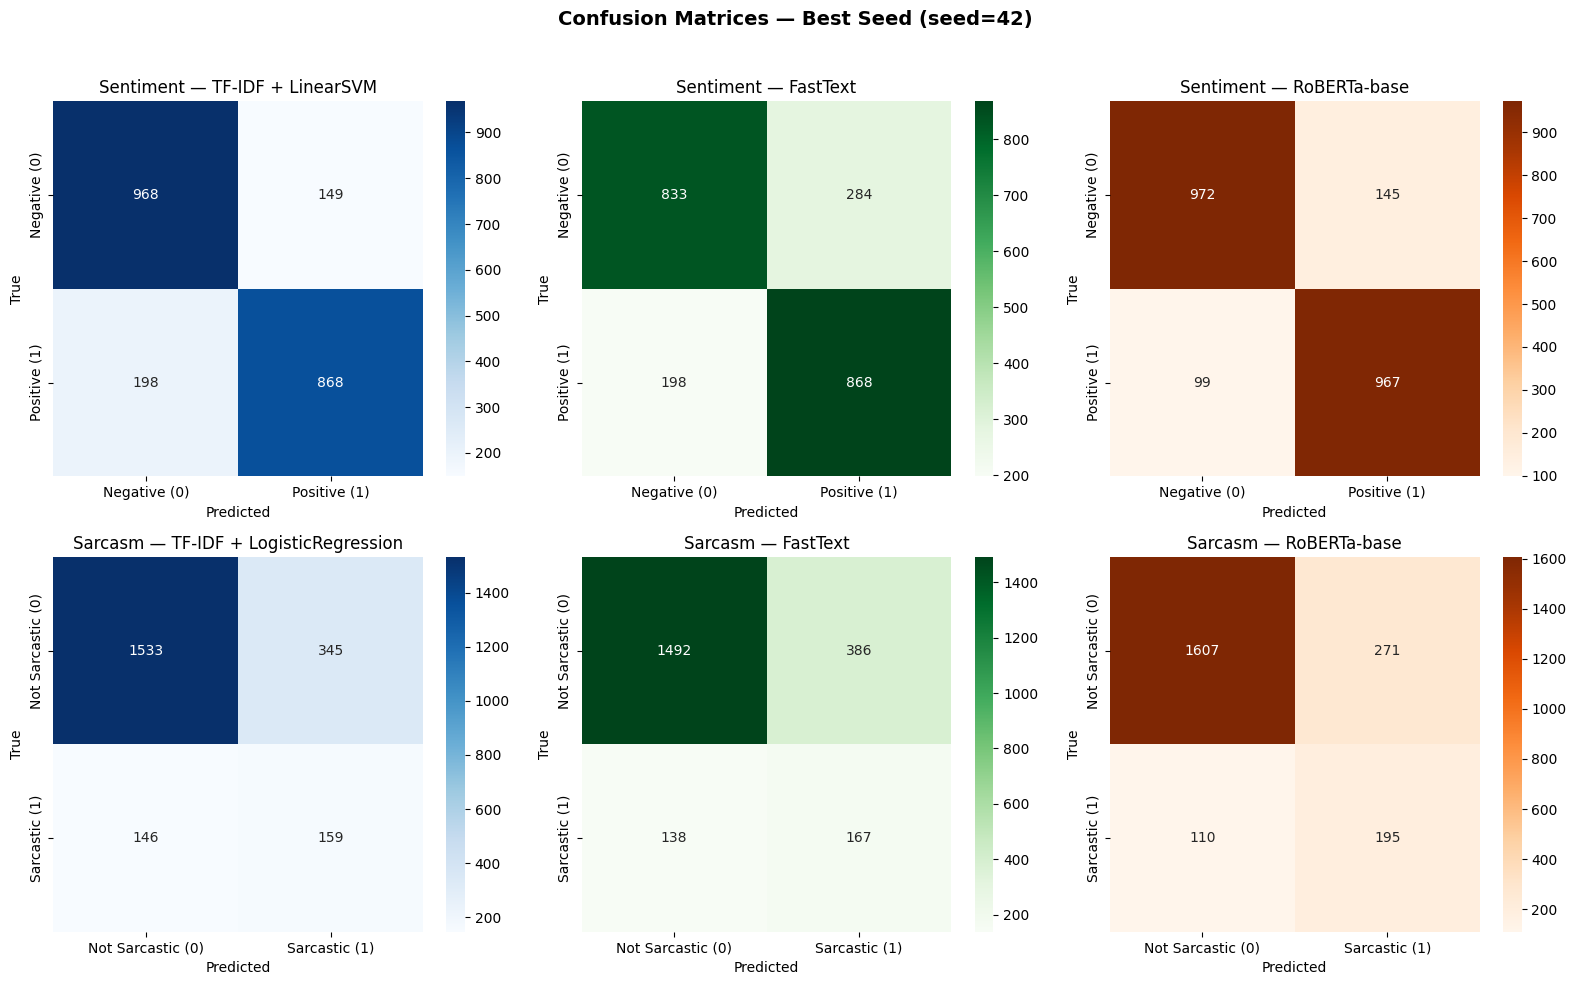

Saved: confusion_matrices_q2_1.png


In [28]:
# Confusion matrices, 2 rows (Sentiment, Sarcasm) and 3 cols (TF-IDF, FastText, RoBERTa)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices - Best Seed (seed=42)', fontsize=14, fontweight='bold')

class_labels = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm': ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for row_idx, (task_name, label_col) in enumerate([
    ("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)
]):
    labels = class_labels[task_name]

    # Column 0: TF-IDF
    clf_name = best_classical[task_name]
    cm = classical_all_results[task_name][clf_name][0]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f'{task_name} - TF-IDF + {clf_name}')
    axes[row_idx, 0].set_ylabel('True')
    axes[row_idx, 0].set_xlabel('Predicted')

    # Column 1: FastText
    cm_ft = classical_all_results[task_name]['FastText'][0]['cm']
    sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels, yticklabels=labels, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f'{task_name} - FastText')
    axes[row_idx, 1].set_ylabel('True')
    axes[row_idx, 1].set_xlabel('Predicted')

    # Column 2: RoBERTa
    cm_r = transformer_all_results[task_name][0]['cm']
    sns.heatmap(cm_r, annot=True, fmt='d', cmap='Oranges',
                xticklabels=labels, yticklabels=labels, ax=axes[row_idx, 2])
    axes[row_idx, 2].set_title(f'{task_name} - RoBERTa-base')
    axes[row_idx, 2].set_ylabel('True')
    axes[row_idx, 2].set_xlabel('Predicted')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('confusion_matrices_q2_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_q2_1.png")

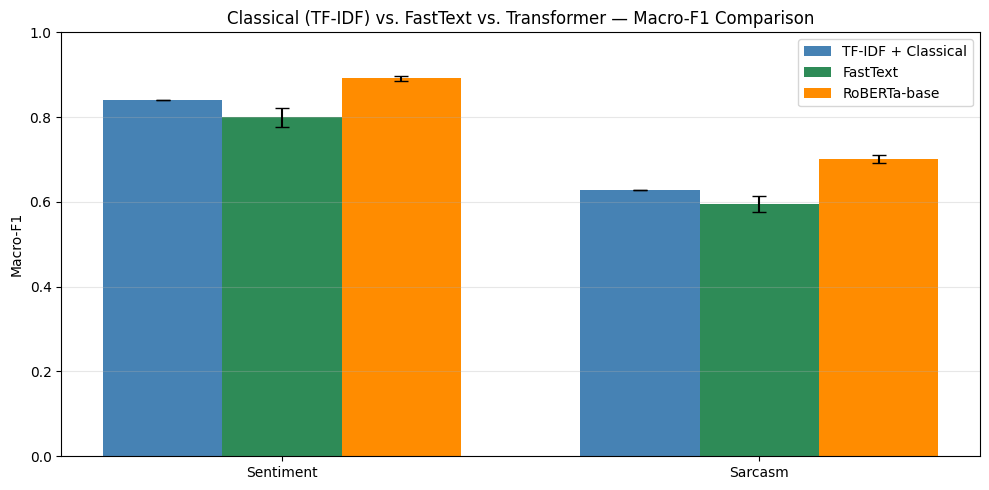

Saved: macro_f1_comparison_q2_1.png


In [29]:
# Bar chart comparing Macro-F1 with error bars across the 3 models
fig, ax = plt.subplots(figsize=(10, 5))

bar_data = []
for task_name in ["Sentiment", "Sarcasm"]:
    clf_name = best_classical[task_name]
    c_f1s = [r['macro_f1'] for r in classical_all_results[task_name][clf_name]]
    ft_f1s = [r['macro_f1'] for r in classical_all_results[task_name]['FastText']]
    t_f1s = [r['macro_f1'] for r in transformer_all_results[task_name]]

    bar_data.append({
        'task': task_name,
        'tfidf_mean': np.mean(c_f1s), 'tfidf_std': np.std(c_f1s),
        'ft_mean': np.mean(ft_f1s), 'ft_std': np.std(ft_f1s),
        'roberta_mean': np.mean(t_f1s), 'roberta_std': np.std(t_f1s),
    })

x = np.arange(len(bar_data))
width = 0.25

ax.bar(x - width,
       [d['tfidf_mean'] for d in bar_data],
       width, yerr=[d['tfidf_std'] for d in bar_data],
       label='TF-IDF + Classical', color='steelblue', capsize=5)
ax.bar(x,
       [d['ft_mean'] for d in bar_data],
       width, yerr=[d['ft_std'] for d in bar_data],
       label='FastText', color='seagreen', capsize=5)
ax.bar(x + width,
       [d['roberta_mean'] for d in bar_data],
       width, yerr=[d['roberta_std'] for d in bar_data],
       label='RoBERTa-base', color='darkorange', capsize=5)

ax.set_ylabel('Macro-F1')
ax.set_title('Classical (TF-IDF) vs FastText vs Transformer - Macro-F1 Comparison')
ax.set_xticks(x)
ax.set_xticklabels([d['task'] for d in bar_data])
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('macro_f1_comparison_q2_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: macro_f1_comparison_q2_1.png")

### 5.1 Inference Time and Efficiency
This section measures inference efficiency by evaluating each model on the BESSTIE test set. Results are summarised in terms of total inference time, average latency per sample, throughput, and predictive performance.

In [30]:
RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# DataFrame to store inference results for all the models
inference_data_all = []

# 1. Get inference times for the classical models (TF-IDF + LR/SVM) and FastText
for task_name, model_results in classical_all_results.items():
    for model_name, runs in model_results.items():
        for run_idx, res in enumerate(runs):
            inference_data_all.append({
                'Model': model_name,
                'Task': task_name,
                'Run': run_idx + 1,
                'Inference Time (Total ms)': res['inference_time_total_ms'],
                'Inference Time per Sample (ms)': res['inference_time_per_sample_ms'],
                'Macro-F1': res['macro_f1'],
                'Precision': res['macro_precision'],
                'Recall': res['macro_recall'],
            })

# 2. Get inference times for RoBERTa from transformer_all_results
for task_name, results in transformer_all_results.items():
    for res in results:
        inference_data_all.append({
            'Model': 'RoBERTa',
            'Task': task_name,
            'Run': 1,
            'Inference Time (Total ms)': res['inference_time_total_ms'],
            'Inference Time per Sample (ms)': res['inference_time_per_sample_ms'],
            'Macro-F1': res['macro_f1'],
            'Precision': res['macro_precision'],
            'Recall': res['macro_recall']
        })

# Save results to a DataFrame and write to csv
df_inference_all = pd.DataFrame(inference_data_all)
df_inference_all.to_csv(f"{RESULTS_DIR}/all_models_inference.csv", index=False)

# Show the DataFrame so we can check it
display(df_inference_all)

print(f"Inference results saved to {RESULTS_DIR}/all_models_inference.csv")

,Model,Task,Run,Inference Time (Total ms),Inference Time per Sample (ms),Macro-F1,Precision,Recall
0,LogisticRegression,Sentiment,1,647.877455,0.296783,0.828746,0.830001,0.828473
1,LogisticRegression,Sentiment,2,538.065434,0.246480,0.828746,0.830001,0.828473
2,LogisticRegression,Sentiment,3,601.534128,0.275554,0.828746,0.830001,0.828473
3,LinearSVM,Sentiment,1,618.398905,0.283279,0.840710,0.841840,0.840433
4,LinearSVM,Sentiment,2,426.927805,0.195569,0.840710,0.841840,0.840433
5,LinearSVM,Sentiment,3,413.208723,0.189285,0.840710,0.841840,0.840433
6,FastText,Sentiment,1,128.589869,0.058905,0.779146,0.780713,0.780003
7,FastText,Sentiment,2,630.228758,0.288698,0.837832,0.838016,0.838156
8,FastText,Sentiment,3,112.614870,0.051587,0.802947,0.804958,0.803922
9,LogisticRegression,Sarcasm,1,667.529106,0.305785,0.627520,0.614260,0.668803


Inference results saved to ./results/all_models_inference.csv


## 6. Error Analysis - Where Does Each Model Fail?

In [31]:
# Find cases where one model gets it right but the other gets it wrong
for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    y_test = np.array(pooled['test'][label_col])
    texts_test = list(pooled['test'][text_col])  # convert to list to avoid numpy indexing issues

    y_classical = classical_all_results[task_name][clf_name][0]['y_pred']
    y_roberta   = transformer_all_results[task_name][0]['y_pred']

    # RoBERTa right, classical wrong
    roberta_wins = np.where((y_roberta == y_test) & (y_classical != y_test))[0]
    # Classical right, RoBERTa wrong
    classical_wins = np.where((y_classical == y_test) & (y_roberta != y_test))[0]

    print(f"\nERROR ANALYSIS - {task_name.upper()}")
    print(f"  RoBERTa correct and Classical wrong: {len(roberta_wins)} samples")
    print(f"  Classical correct and RoBERTa wrong: {len(classical_wins)} samples")

    # Print up to 5 examples for each case
    print(f"\n  Examples where RoBERTa is right but Classical is wrong:")
    for i in roberta_wins[:5]:
        txt = texts_test[i][:120]
        print(f"    True={y_test[i]}  Classical={y_classical[i]}  RoBERTa={y_roberta[i]}  "
              f"Text: {txt}...")

    print(f"\n  Examples where Classical is right but RoBERTa is wrong:")
    for i in classical_wins[:5]:
        txt = texts_test[i][:120]
        print(f"    True={y_test[i]}  Classical={y_classical[i]}  RoBERTa={y_roberta[i]}  "
              f"Text: {txt}...")


ERROR ANALYSIS — SENTIMENT
  RoBERTa correct & Classical wrong: 198 samples
  Classical correct & RoBERTa wrong: 95 samples

  --- Examples where RoBERTa succeeds but Classical fails ---
    True=1.0  Classical=0.0  RoBERTa=1  Text: Best Dosa in Aizawl as far as I know. Their specials are also never a missed. I do recommend this place to anyone...
    True=1.0  Classical=0.0  RoBERTa=1  Text: why tho ? 100K GBP is enough to live a decent life in London, and London is a much better place than Bangalore, being ab...
    True=1.0  Classical=0.0  RoBERTa=1  Text: They have their own Brand. This is one of the outlets. Try their Khari Biscuits Plain & Methi flavors...
    True=1.0  Classical=0.0  RoBERTa=1  Text: This is so wholesome....
    True=1.0  Classical=0.0  RoBERTa=1  Text: We have everything from tropics to desert to alpine with snow. Depends entirely on where you are going and a bit on what...

  --- Examples where Classical succeeds but RoBERTa fails ---
    True=0.0  Classical=

### 6.1 Per-Class Metric Comparison - Classical vs. Transformer

A direct side-by-side view of per-class Precision, Recall, and F1 reveals *where* each model gains or loses. This is critical for sarcasm, where the minority-class recall determines whether the model has genuinely learned the task or is simply predicting the majority class.

In [32]:
# Per-class metric comparison: classical vs RoBERTa for each task
# Recompute reports with explicit int labels so dict keys are '0' and '1'
per_class_rows = []

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    y_test_int = np.array(pooled['test'][label_col]).astype(int)
    y_pred_c   = np.array(classical_all_results[task_name][clf_name][0]['y_pred']).astype(int)
    y_pred_r   = np.array(transformer_all_results[task_name][0]['y_pred']).astype(int)

    classical_report = classification_report(y_test_int, y_pred_c, labels=[0, 1], output_dict=True)
    roberta_report   = classification_report(y_test_int, y_pred_r, labels=[0, 1], output_dict=True)

    class_names = {
        'Sentiment': {0: 'Negative', 1: 'Positive'},
        'Sarcasm':   {0: 'Not Sarcastic', 1: 'Sarcastic'},
    }

    for cls_idx in [0, 1]:
        cls_key = str(cls_idx)
        cls_label = class_names[task_name][cls_idx]
        c = classical_report[cls_key]
        r = roberta_report[cls_key]
        per_class_rows.append({
            'Task': task_name,
            'Class': f'{cls_label} ({cls_idx})',
            'Classical P': f"{c['precision']:.3f}",
            'Classical R': f"{c['recall']:.3f}",
            'Classical F1': f"{c['f1-score']:.3f}",
            'RoBERTa P': f"{r['precision']:.3f}",
            'RoBERTa R': f"{r['recall']:.3f}",
            'RoBERTa F1': f"{r['f1-score']:.3f}",
            'F1 diff': f"{r['f1-score'] - c['f1-score']:+.3f}",
        })

per_class_df = pd.DataFrame(per_class_rows)
print("PER-CLASS COMPARISON (seed=42)")
display(per_class_df)

# Check the sarcasm minority class recall
print("\nSARCASM MINORITY CLASS (Sarcastic=1) RECALL CHECK")
sarc_c = classification_report(
    np.array(pooled['test'][sarcasm_col]).astype(int),
    np.array(classical_all_results['Sarcasm'][best_classical['Sarcasm']][0]['y_pred']).astype(int),
    labels=[0, 1], output_dict=True
)['1']
sarc_r = classification_report(
    np.array(pooled['test'][sarcasm_col]).astype(int),
    np.array(transformer_all_results['Sarcasm'][0]['y_pred']).astype(int),
    labels=[0, 1], output_dict=True
)['1']
print(f"  Classical ({best_classical['Sarcasm']}): Recall = {sarc_c['recall']:.3f}  "
      f"(predicts sarcasm {sarc_c['recall']*100:.1f}% of the time when it is sarcastic)")
print(f"  RoBERTa:                Recall = {sarc_r['recall']:.3f}  "
      f"(predicts sarcasm {sarc_r['recall']*100:.1f}% of the time when it is sarcastic)")
print(f"  Neither model just predicts the majority class (recall is above 0).")
print(f"  RoBERTa recall advantage: {sarc_r['recall'] - sarc_c['recall']:+.3f} "
      f"({(sarc_r['recall'] - sarc_c['recall'])/sarc_c['recall']*100:+.1f}% relative improvement)")

PER-CLASS COMPARISON (seed=42)


,Task,Class,Classical P,Classical R,Classical F1,RoBERTa P,RoBERTa R,RoBERTa F1,F1 Δ
0,Sentiment,Negative (0),0.830,0.867,0.848,0.908,0.870,0.888,+0.040
1,Sentiment,Positive (1),0.853,0.814,0.833,0.870,0.907,0.888,+0.055
2,Sarcasm,Not Sarcastic (0),0.913,0.816,0.862,0.936,0.856,0.894,+0.032
3,Sarcasm,Sarcastic (1),0.315,0.521,0.393,0.418,0.639,0.506,+0.113



>>> SARCASM MINORITY-CLASS (Sarcastic=1) RECALL CHECK <<<
  Classical (LogisticRegression): Recall = 0.521  (predicts sarcasm 52.1% of the time when it is sarcastic)
  RoBERTa:                Recall = 0.639  (predicts sarcasm 63.9% of the time when it is sarcastic)
  → Neither model collapses to majority-class prediction (recall > 0).
  → RoBERTa recall advantage: +0.118 (+22.6% relative improvement)


### 6.2 Per-Variety Gap Analysis

To understand whether the Transformer's advantage is uniform or variety-dependent, we break down the test-set Macro-F1 by variety. This reveals whether certain English varieties (e.g., en-IN with potential code-mixing) benefit more from RoBERTa's subword tokeniser and contextual representations.

PER-VARIETY MACRO-F1 BREAKDOWN (seed=42)


,Task,Variety,N (test),Classical F1,RoBERTa F1,Δ F1
0,Sentiment,en-AU,667,0.830,0.892,+0.062
1,Sentiment,en-IN,816,0.804,0.844,+0.040
2,Sentiment,en-UK,700,0.891,0.935,+0.044
3,Sarcasm,en-AU,667,0.671,0.767,+0.096
4,Sarcasm,en-IN,816,0.547,0.543,-0.004
5,Sarcasm,en-UK,700,0.589,0.661,+0.071


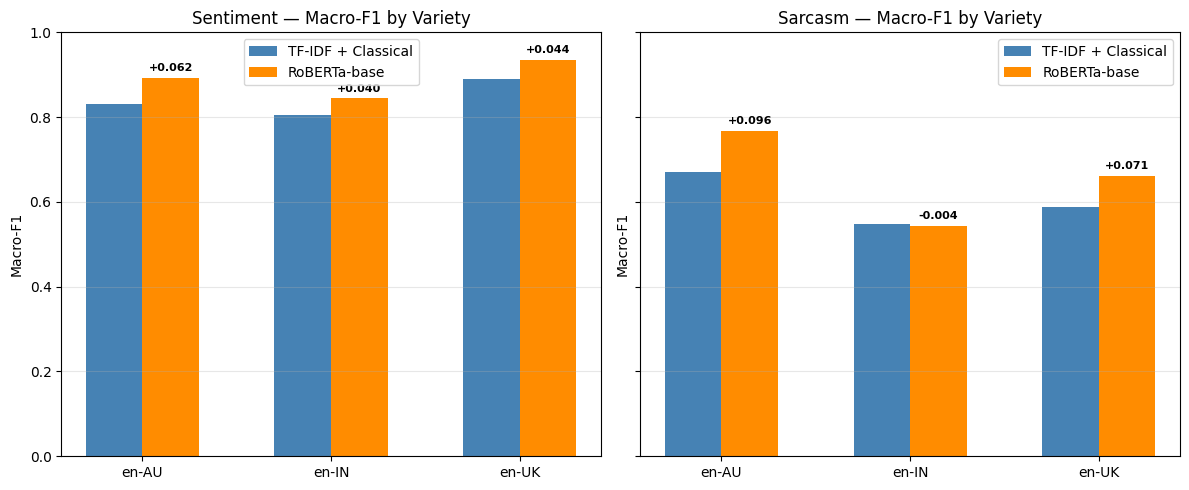

Saved: per_variety_comparison_q2_1.png


In [33]:
# Per-variety Macro-F1 breakdown using seed=42 predictions
test_varieties = list(pooled['test']['variety'])
variety_gap_rows = []

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    y_test_all = np.array(pooled['test'][label_col]).astype(int)
    y_classical = np.array(classical_all_results[task_name][clf_name][0]['y_pred']).astype(int)
    y_roberta   = np.array(transformer_all_results[task_name][0]['y_pred']).astype(int)

    for variety in ["en-AU", "en-IN", "en-UK"]:
        mask = np.array([v == variety for v in test_varieties])
        y_true_v = y_test_all[mask]
        y_c_v = y_classical[mask]
        y_r_v = y_roberta[mask]

        f1_c = f1_score(y_true_v, y_c_v, average='macro')
        f1_r = f1_score(y_true_v, y_r_v, average='macro')

        variety_gap_rows.append({
            'Task': task_name,
            'Variety': variety,
            'N (test)': int(mask.sum()),
            'Classical F1': f"{f1_c:.3f}",
            'RoBERTa F1': f"{f1_r:.3f}",
            'F1 diff': f"{f1_r - f1_c:+.3f}",
            'delta_raw': f1_r - f1_c,
        })

variety_df = pd.DataFrame(variety_gap_rows)
print("PER-VARIETY MACRO-F1 BREAKDOWN (seed=42)")
display(variety_df[['Task', 'Variety', 'N (test)', 'Classical F1', 'RoBERTa F1', 'F1 diff']])

# Bar chart showing the gap per variety per task
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax_idx, task_name in enumerate(["Sentiment", "Sarcasm"]):
    task_data = [r for r in variety_gap_rows if r['Task'] == task_name]
    vars_ = [r['Variety'] for r in task_data]
    classical_f1s = [float(r['Classical F1']) for r in task_data]
    roberta_f1s = [float(r['RoBERTa F1']) for r in task_data]

    x = np.arange(len(vars_))
    w = 0.3
    axes[ax_idx].bar(x - w/2, classical_f1s, w, label='TF-IDF + Classical', color='steelblue')
    axes[ax_idx].bar(x + w/2, roberta_f1s, w, label='RoBERTa-base', color='darkorange')
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(vars_)
    axes[ax_idx].set_title(f'{task_name} - Macro-F1 by Variety')
    axes[ax_idx].set_ylabel('Macro-F1')
    axes[ax_idx].set_ylim(0, 1)
    axes[ax_idx].legend()
    axes[ax_idx].grid(axis='y', alpha=0.3)

    # Show the gap on the chart
    for i, td in enumerate(task_data):
        gap = td['delta_raw']
        mid = (float(td['Classical F1']) + float(td['RoBERTa F1'])) / 2
        axes[ax_idx].annotate(f'{gap:+.3f}', xy=(i + w/2, float(td['RoBERTa F1'])),
                              xytext=(0, 5), textcoords='offset points',
                              ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('per_variety_comparison_q2_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_variety_comparison_q2_1.png")

In [34]:
# Print final summary so it is easy to copy into the report
print("\nQ2.1 FINAL RESULTS SUMMARY")
print("\nAll results are mean and std over 3 runs (seeds: 42, 123, 456).")
print("TF-IDF vectoriser: max_features=50k, ngram_range=(1,2), sublinear_tf=True.")
print("RoBERTa: roberta-base, lr=2e-5, batch=16, max 5 epochs, early stopping.")
print("Class imbalance handled by balanced class weights in all models.")
print(f"\nPooled data: Train={len(pooled['train'])}, "
      f"Val={len(pooled['validation'])}, Test={len(pooled['test'])}")
print()
display(comparison_df[['Task', 'Model', 'Macro-F1', 'Precision', 'Recall']])


Q2.1 FINAL RESULTS SUMMARY

All results reported as mean ± std over 3 runs (seeds: 42, 123, 456).
TF-IDF vectoriser: max_features=50k, ngram_range=(1,2), sublinear_tf=True.
RoBERTa: roberta-base, lr=2e-5, batch=16, max 5 epochs, early stopping.
Class imbalance handled via balanced class weights in all models.

Pooled data: Train=3747, Val=313, Test=2183



,Task,Model,Macro-F1,Precision,Recall
0,Sentiment,TF-IDF + LinearSVM,0.8407 ± 0.0000,0.8418 ± 0.0000,0.8404 ± 0.0000
1,Sentiment,FastText (supervised),0.7991 ± 0.0227,0.8008 ± 0.0223,0.8000 ± 0.0226
2,Sentiment,RoBERTa-base (fine-tuned),0.8915 ± 0.0054,0.8917 ± 0.0054,0.8916 ± 0.0053
3,Sarcasm,TF-IDF + LogisticRegression,0.6275 ± 0.0000,0.6143 ± 0.0000,0.6688 ± 0.0000
4,Sarcasm,FastText (supervised),0.5950 ± 0.0189,0.6087 ± 0.0029,0.6051 ± 0.0470
5,Sarcasm,RoBERTa-base (fine-tuned),0.7004 ± 0.0096,0.6805 ± 0.0093,0.7365 ± 0.0124


---
*End of Q2.1 experiments. Figures saved to `confusion_matrices_q2_1.png`, `macro_f1_comparison_q2_1.png`, and `per_variety_comparison_q2_1.png`.*

---
## Q2.2 - Cross-Variety Evaluation (RoBERTa on Sentiment)

**Objective:** Train RoBERTa-base on each English variety (en-AU, en-IN, en-UK) **individually**
and evaluate on all three test sets to assess cross-variety transferability.

- **Model:** RoBERTa-base (same pre-trained encoder as Q2.1)
- **Task:** Sentiment classification
- **Seeds:** 2 runs per variety (42, 123) to ensure robustness
- **Evaluation:** 3×3 matrix - each model tested on all varieties

In [ ]:
# -- Q2.2: Prepare variety-specific splits -------------------------------------
# VARIETIES, CROSS_SEEDS, CROSS_TASK are defined in the imports cell (Section 1)
cross_label_col = sentiment_col  # Change to sarcasm_col for Sarcasm task

# Split pooled data by variety
variety_splits = {}
for variety in VARIETIES:
    variety_splits[variety] = {}
    for split_name in ["train", "validation", "test"]:
        mask = [v == variety for v in pooled[split_name]["variety"]]
        texts = [t for t, m in zip(pooled[split_name][text_col], mask) if m]
        labels = [int(l) for l, m in zip(pooled[split_name][cross_label_col], mask) if m]
        variety_splits[variety][split_name] = (texts, labels)
    tr = len(variety_splits[variety]["train"][0])
    va = len(variety_splits[variety]["validation"][0])
    te = len(variety_splits[variety]["test"][0])
    print(f"{variety}: train={tr}, val={va}, test={te}")



if not LOAD_FROM_SAVED:
    def run_cross_variety_roberta(train_variety, seed):
        """
        Train RoBERTa on one variety's data, then evaluate on ALL three test sets.
        Returns dict: {test_variety: {y_pred, macro_f1, macro_precision, macro_recall, report, cm}}
        """
        set_seed(seed)
        print(f"  Loading tokenizer & model ...")

        tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        model = RobertaForSequenceClassification.from_pretrained(
            'roberta-base', num_labels=2
        ).to(DEVICE)

        train_texts, train_labels = variety_splits[train_variety]["train"]
        val_texts, val_labels = variety_splits[train_variety]["validation"]

        train_ds = TextClassificationDataset(train_texts, train_labels, tokenizer)
        val_ds   = TextClassificationDataset(val_texts,   val_labels,   tokenizer)

        cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(train_labels))
        print(f"  Class weights: {cw}")

        output_dir = f"./roberta_cv_{train_variety}_{CROSS_TASK.lower()}_s{seed}"

        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_ratio=0.1,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='macro_f1',
            greater_is_better=True,
            save_total_limit=1,
            logging_steps=50,
            seed=seed,
            fp16=torch.cuda.is_available(),
            report_to='none',
        )

        trainer = WeightedTrainer(
            class_weights=cw,
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics_for_trainer,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        )

        trainer.train()

        # Evaluate on each variety's test set
        results = {}
        for test_variety in VARIETIES:
            test_texts, test_labels = variety_splits[test_variety]["test"]
            test_ds = TextClassificationDataset(test_texts, test_labels, tokenizer)
            preds_out = trainer.predict(test_ds)
            y_pred = np.argmax(preds_out.predictions, axis=-1)
            y_true = np.array(test_labels)

            results[test_variety] = {
                'y_pred': y_pred,
                'y_true': y_true,
                'macro_f1': f1_score(y_true, y_pred, average='macro'),
                'macro_precision': precision_score(y_true, y_pred, average='macro'),
                'macro_recall': recall_score(y_true, y_pred, average='macro'),
                'report': classification_report(y_true, y_pred, output_dict=True),
                'cm': confusion_matrix(y_true, y_pred),
            }

        # Save the best model and tokenizer for later reuse
        save_path = os.path.join(SAVE_DIR, f"roberta_cv_{train_variety}_{CROSS_TASK.lower()}_seed{seed}")
        os.makedirs(save_path, exist_ok=True)
        trainer.model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)
        print(f"    Model saved to {save_path}")

        # Cleanup training checkpoints (keep only the saved model)
        import shutil
        if os.path.exists(output_dir) and os.path.abspath(output_dir) != os.path.abspath(save_path):
            shutil.rmtree(output_dir)

        return results

    print("\n Cross-variety function defined. Ready to train.")

else:
    print("⏭ Cross-variety training function not needed (results loaded from pkl files)")

en-AU: train=1145, val=95, test=667
en-IN: train=1399, val=117, test=816
en-UK: train=1203, val=101, test=700
⏭ Cross-variety training function not needed (results loaded from pkl files)


In [ ]:
# -- Run cross-variety experiments ---------------------------------------------
# NOTE: Trains 6 RoBERTa models (3 varieties × 2 seeds).

if not LOAD_FROM_SAVED:

    cross_variety_results = {}  # key: (train_variety, seed) → {test_variety: metrics}

    for train_v in VARIETIES:
        for seed in CROSS_SEEDS:
            print(f"\n{'='*60}")
            print(f"Training RoBERTa on {train_v} (seed={seed})")
            print(f"{'='*60}")
            cross_variety_results[(train_v, seed)] = run_cross_variety_roberta(train_v, seed)

            for test_v in VARIETIES:
                marker = " ◆ (in-dist)" if train_v == test_v else ""
                f1 = cross_variety_results[(train_v, seed)][test_v]['macro_f1']
                print(f"  → Test {test_v}: Macro-F1 = {f1:.4f}{marker}")

    print("\n Cross-variety evaluation complete - all 6 models trained & evaluated.")

else:
    print("⏭ Skipping cross-variety training (results loaded from pkl files)")

⏭ Skipping cross-variety training (results loaded from pkl files)


In [ ]:
# -- Save cross-variety results to disk ------------------------------------
if not LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "cross_variety_results.pkl"), "wb") as f:
        pickle.dump(cross_variety_results, f)
    print(f" Cross-variety results saved to {SAVE_DIR}/")
else:
    print("⏭ Skipping save (results already on disk)")

⏭ Skipping save (results already on disk)



CROSS-VARIETY EVALUATION — SENTIMENT (RoBERTa, mean ± std over 2 seeds)
Train Variety    Test Variety         Macro-F1  Precision     Recall
-------------------------------------------------------------------------------------
en-AU            en-AU          0.8929±0.0035      0.8971     0.8922 ◆
en-AU            en-IN          0.8215±0.0055      0.8255     0.8242  
en-AU            en-UK          0.9399±0.0042      0.9418     0.9402  
en-IN            en-AU          0.8913±0.0061      0.8959     0.8901  
en-IN            en-IN          0.8410±0.0029      0.8411     0.8416 ◆
en-IN            en-UK          0.9392±0.0036      0.9392     0.9393  
en-UK            en-AU          0.8634±0.0181      0.8797     0.8620  
en-UK            en-IN          0.8451±0.0015      0.8477     0.8443  
en-UK            en-UK          0.9493±0.0007      0.9493     0.9494 ◆
-------------------------------------------------------------------------------------
◆ = In-distribution (same variety for train and

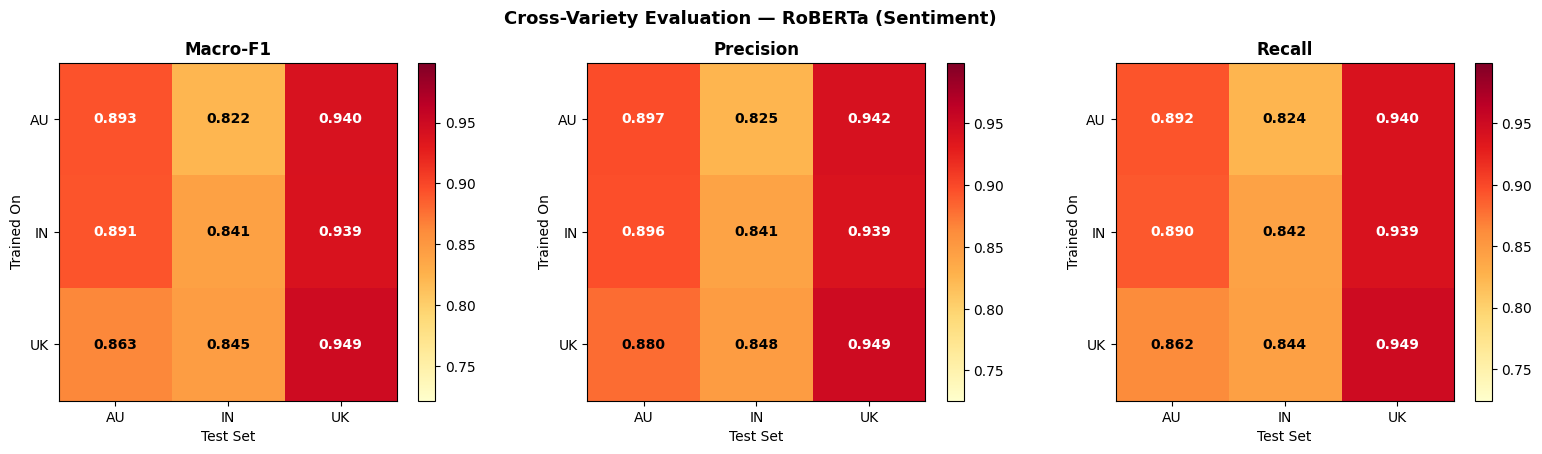

✓ Heatmap saved to cross_variety_heatmap_q2_2.png


In [ ]:
# -- Cross-variety results: average across seeds -----------------------------
cv_avg = {}
for train_v in VARIETIES:
    for test_v in VARIETIES:
        f1s   = [cross_variety_results[(train_v, s)][test_v]['macro_f1'] for s in CROSS_SEEDS]
        precs = [cross_variety_results[(train_v, s)][test_v]['macro_precision'] for s in CROSS_SEEDS]
        recs  = [cross_variety_results[(train_v, s)][test_v]['macro_recall'] for s in CROSS_SEEDS]
        cv_avg[(train_v, test_v)] = {
            'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s),
            'prec_mean': np.mean(precs), 'rec_mean': np.mean(recs),
        }

# Print results table
print("\n" + "="*85)
print(f"CROSS-VARIETY EVALUATION - {CROSS_TASK.upper()} (RoBERTa, mean ± std over {len(CROSS_SEEDS)} seeds)")
print("="*85)
print(f"{'Train Variety':<16} {'Test Variety':<14} {'Macro-F1':>14} {'Precision':>10} {'Recall':>10}")
print("-"*85)
for train_v in VARIETIES:
    for test_v in VARIETIES:
        r = cv_avg[(train_v, test_v)]
        marker = " ◆" if train_v == test_v else "  "
        print(f"{train_v:<16} {test_v:<14} "
              f"{r['f1_mean']:.4f}±{r['f1_std']:.4f}  "
              f"{r['prec_mean']:>10.4f} {r['rec_mean']:>10.4f}{marker}")
print("-"*85)
print("◆ = In-distribution (same variety for train and test)")

# Save results to CSV
cv_rows = []
for train_v in VARIETIES:
    for test_v in VARIETIES:
        r = cv_avg[(train_v, test_v)]
        cv_rows.append({
            'train_variety': train_v, 'test_variety': test_v,
            'macro_f1_mean': r['f1_mean'], 'macro_f1_std': r['f1_std'],
            'precision_mean': r['prec_mean'], 'recall_mean': r['rec_mean'],
        })
pd.DataFrame(cv_rows).to_csv("cross_variety_results_q2_2.csv", index=False)
print("\n Results saved to cross_variety_results_q2_2.csv")

# -- Heatmap ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(f"Cross-Variety Evaluation - RoBERTa ({CROSS_TASK})", fontsize=13, fontweight="bold")
short = [v.replace("en-", "") for v in VARIETIES]

for ax, (metric_key, title) in zip(axes, [
    ("f1_mean", "Macro-F1"), ("prec_mean", "Precision"), ("rec_mean", "Recall"),
]):
    M = np.zeros((len(VARIETIES), len(VARIETIES)))
    for i, tv in enumerate(VARIETIES):
        for j, testv in enumerate(VARIETIES):
            M[i, j] = cv_avg[(tv, testv)][metric_key]

    im = ax.imshow(M, cmap="YlOrRd", vmin=max(0.3, M.min()-0.1), vmax=min(1.0, M.max()+0.05))
    ax.set_xticks(range(len(VARIETIES))); ax.set_yticks(range(len(VARIETIES)))
    ax.set_xticklabels(short); ax.set_yticklabels(short)
    ax.set_xlabel("Test Set"); ax.set_ylabel("Trained On")
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(len(VARIETIES)):
        for j in range(len(VARIETIES)):
            col = "white" if M[i,j] > (M.min()+M.max())/2 else "black"
            ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center",
                    color=col, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("cross_variety_heatmap_q2_2.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Heatmap saved to cross_variety_heatmap_q2_2.png")

TRANSFERABILITY ANALYSIS

  en-AU model:
    In-distribution F1   : 0.8929
    Avg cross-variety F1 : 0.8807
    Performance drop     : 0.0122 (1.4%)

  en-IN model:
    In-distribution F1   : 0.8410
    Avg cross-variety F1 : 0.9153
    Performance drop     : -0.0742 (-8.8%)

  en-UK model:
    In-distribution F1   : 0.9493
    Avg cross-variety F1 : 0.8543
    Performance drop     : 0.0950 (10.0%)

  Inner-circle ↔ Inner-circle transfer (UK ↔ AU):
    UK→AU: 0.8634,  AU→UK: 0.9399,  avg: 0.9017

  Inner ↔ Outer-circle transfer (UK/AU ↔ IN):
    UK→IN: 0.8451,  IN→UK: 0.9392
    AU→IN: 0.8215,  IN→AU: 0.8913
    Avg inner↔outer: 0.8743


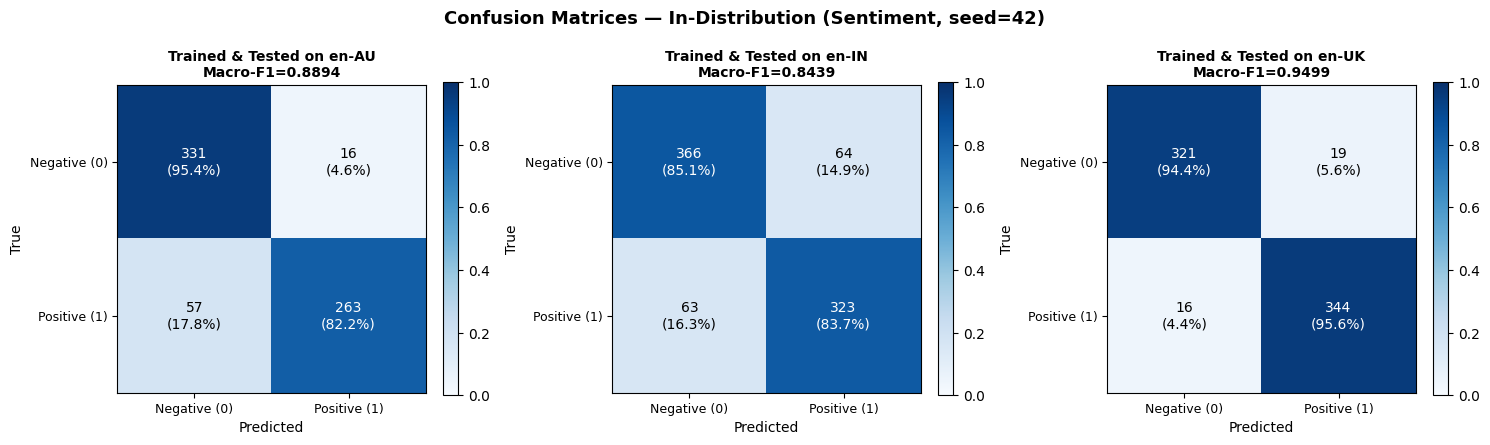

✓ In-distribution confusion matrices saved to confusion_matrices_q2_2_indist.png


In [ ]:
# -- Transferability Analysis -------------------------------------------------
print("TRANSFERABILITY ANALYSIS")
print("="*65)

for train_v in VARIETIES:
    in_d = cv_avg[(train_v, train_v)]['f1_mean']
    cross_f1s = [cv_avg[(train_v, tv)]['f1_mean'] for tv in VARIETIES if tv != train_v]
    avg_cross = np.mean(cross_f1s)
    drop = in_d - avg_cross
    drop_pct = 100 * drop / in_d if in_d > 0 else 0
    print(f"\n  {train_v} model:")
    print(f"    In-distribution F1   : {in_d:.4f}")
    print(f"    Avg cross-variety F1 : {avg_cross:.4f}")
    print(f"    Performance drop     : {drop:.4f} ({drop_pct:.1f}%)")

# Inner-circle (UK/AU) vs outer-circle (IN) comparison
print("\n  Inner-circle ↔ Inner-circle transfer (UK ↔ AU):")
uk_au = cv_avg[("en-UK", "en-AU")]['f1_mean']
au_uk = cv_avg[("en-AU", "en-UK")]['f1_mean']
print(f"    UK→AU: {uk_au:.4f},  AU→UK: {au_uk:.4f},  avg: {(uk_au+au_uk)/2:.4f}")

print("\n  Inner ↔ Outer-circle transfer (UK/AU ↔ IN):")
uk_in = cv_avg[("en-UK", "en-IN")]['f1_mean']
in_uk = cv_avg[("en-IN", "en-UK")]['f1_mean']
au_in = cv_avg[("en-AU", "en-IN")]['f1_mean']
in_au = cv_avg[("en-IN", "en-AU")]['f1_mean']
print(f"    UK→IN: {uk_in:.4f},  IN→UK: {in_uk:.4f}")
print(f"    AU→IN: {au_in:.4f},  IN→AU: {in_au:.4f}")
print(f"    Avg inner↔outer: {np.mean([uk_in, in_uk, au_in, in_au]):.4f}")

# -- Confusion Matrices - in-distribution (best seed) ------------------------
seed0 = CROSS_SEEDS[0]
cls_labels = ['Negative (0)', 'Positive (1)']

fig, axes = plt.subplots(1, len(VARIETIES), figsize=(5*len(VARIETIES), 4.5))
fig.suptitle(f"Confusion Matrices - In-Distribution ({CROSS_TASK}, seed={seed0})",
             fontsize=13, fontweight="bold")

for ax, train_v in zip(axes, VARIETIES):
    r = cross_variety_results[(train_v, seed0)][train_v]
    cm = r['cm']
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_n, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(cls_labels, fontsize=9)
    ax.set_yticklabels(cls_labels, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Trained & Tested on {train_v}\nMacro-F1={r['macro_f1']:.4f}",
                 fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(2):
        for j in range(2):
            col = "white" if cm_n[i,j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i,j]}\n({cm_n[i,j]:.1%})", ha="center", va="center",
                    color=col, fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrices_q2_2_indist.png", dpi=150, bbox_inches="tight")
plt.show()
print(" In-distribution confusion matrices saved to confusion_matrices_q2_2_indist.png")

---
## Q3 - Evaluation Metrics (for Q2.1 & Q2.2)

Formal evaluation across all experiment setups with **Macro-F1** as the primary metric.
Per-class results are reported to verify models predict both classes and do not collapse to majority-class prediction.

In [ ]:
# -- Q3: Consolidated Evaluation Metrics --------------------------------------

print("="*90)
print("Q3 - EVALUATION METRICS SUMMARY")
print("="*90)

# -- helper: look up per-class F1 from report dict, handling str/int/float keys --
def _get_f1(rpt, cls_label):
    """Return f1-score for cls_label, trying '0', 0, '0.0' key formats."""
    for key in [str(cls_label), cls_label, str(float(cls_label)), str(int(cls_label))]:
        if key in rpt:
            return rpt[key].get('f1-score')
    return None

# -- Q2.1 Metrics --
print("\n-- Q2.1: Baseline vs Transformer (Pooled Data) --")
print(f"{'Task':<12} {'Model':<28} {'Macro-F1':>10} {'Precision':>10} {'Recall':>10}")
print("-"*72)

for task_name in ["Sentiment", "Sarcasm"]:
    clf_name = best_classical[task_name]
    c = classical_all_results[task_name][clf_name][0]
    print(f"{task_name:<12} TF-IDF+{clf_name:<20} {c['macro_f1']:>10.4f} "
          f"{c['macro_precision']:>10.4f} {c['macro_recall']:>10.4f}")
    t = transformer_all_results[task_name][0]
    print(f"{'':12} {'RoBERTa-base':<28} {t['macro_f1']:>10.4f} "
          f"{t['macro_precision']:>10.4f} {t['macro_recall']:>10.4f}")

# -- Q2.2 Metrics --
print(f"\n-- Q2.2: Cross-Variety Evaluation ({CROSS_TASK}, RoBERTa) --")
print(f"{'Train→Test':<20} {'Macro-F1':>14} {'Precision':>10} {'Recall':>10}")
print("-"*58)
for train_v in VARIETIES:
    for test_v in VARIETIES:
        r = cv_avg[(train_v, test_v)]
        marker = " ◆" if train_v == test_v else ""
        print(f"{train_v}→{test_v:<10} {r['f1_mean']:>10.4f}±{r['f1_std']:.3f} "
              f"{r['prec_mean']:>10.4f} {r['rec_mean']:>10.4f}{marker}")

# -- Per-class F1: proves model does NOT just predict the majority class --
print(f"\n-- Per-Class F1 - Majority Class Check ({CROSS_TASK}, seed={CROSS_SEEDS[0]}) --")
print(f"{'Setup':<20} {'Class 0 F1':>11} {'Class 1 F1':>11} {'Pred 0':>8} {'Pred 1':>8}")
print("-"*62)

# Q2.1 per-class (pooled, seed=42)
for task_name in ["Sentiment", "Sarcasm"]:
    label_col = sentiment_col if task_name == "Sentiment" else sarcasm_col
    tr_res = transformer_all_results[task_name][0]
    y_p = np.array(tr_res['y_pred'])
    y_true = np.array(pooled['test'][label_col]).astype(int)

    rpt = tr_res.get('report', {}) if isinstance(tr_res, dict) else {}
    f1_0 = _get_f1(rpt, 0)
    f1_1 = _get_f1(rpt, 1)

    if f1_0 is None or f1_1 is None:
        scores = f1_score(y_true, y_p, average=None, labels=[0, 1])
        f1_0, f1_1 = float(scores[0]), float(scores[1])

    n0, n1 = int(np.sum(y_p == 0)), int(np.sum(y_p == 1))
    print(f"Q2.1 RoBERTa({task_name[:4]}) {f1_0:>10.4f} {f1_1:>11.4f} {n0:>8} {n1:>8}")

# Q2.2 per-class (in-distribution only)
for train_v in VARIETIES:
    r = cross_variety_results[(train_v, CROSS_SEEDS[0])][train_v]
    rpt = r.get('report', {})
    f1_0 = _get_f1(rpt, 0)
    f1_1 = _get_f1(rpt, 1)

    if f1_0 is None or f1_1 is None:
        y_true = np.array(r['y_true']).astype(int)
        y_pred = np.array(r['y_pred']).astype(int)
        scores = f1_score(y_true, y_pred, average=None, labels=[0, 1])
        f1_0, f1_1 = float(scores[0]), float(scores[1])

    n0 = int(np.sum(np.array(r['y_pred']) == 0))
    n1 = int(np.sum(np.array(r['y_pred']) == 1))
    print(f"Q2.2 {train_v:<14} {f1_0:>10.4f} {f1_1:>11.4f} {n0:>8} {n1:>8}  ◆")

Q3 — EVALUATION METRICS SUMMARY

── Q2.1: Baseline vs Transformer (Pooled Data) ──
Task         Model                          Macro-F1  Precision     Recall
------------------------------------------------------------------------
Sentiment    TF-IDF+LinearSVM                0.8407     0.8418     0.8404
             RoBERTa-base                     0.8882     0.8886     0.8887
Sarcasm      TF-IDF+LogisticRegression       0.6275     0.6143     0.6688
             RoBERTa-base                     0.6999     0.6772     0.7475

── Q2.2: Cross-Variety Evaluation (Sentiment, RoBERTa) ──
Train→Test                 Macro-F1  Precision     Recall
----------------------------------------------------------
en-AU→en-AU          0.8929±0.004     0.8971     0.8922 ◆
en-AU→en-IN          0.8215±0.006     0.8255     0.8242
en-AU→en-UK          0.9399±0.004     0.9418     0.9402
en-IN→en-AU          0.8913±0.006     0.8959     0.8901
en-IN→en-IN          0.8410±0.003     0.8411     0.8416 ◆
en-IN→en-UK

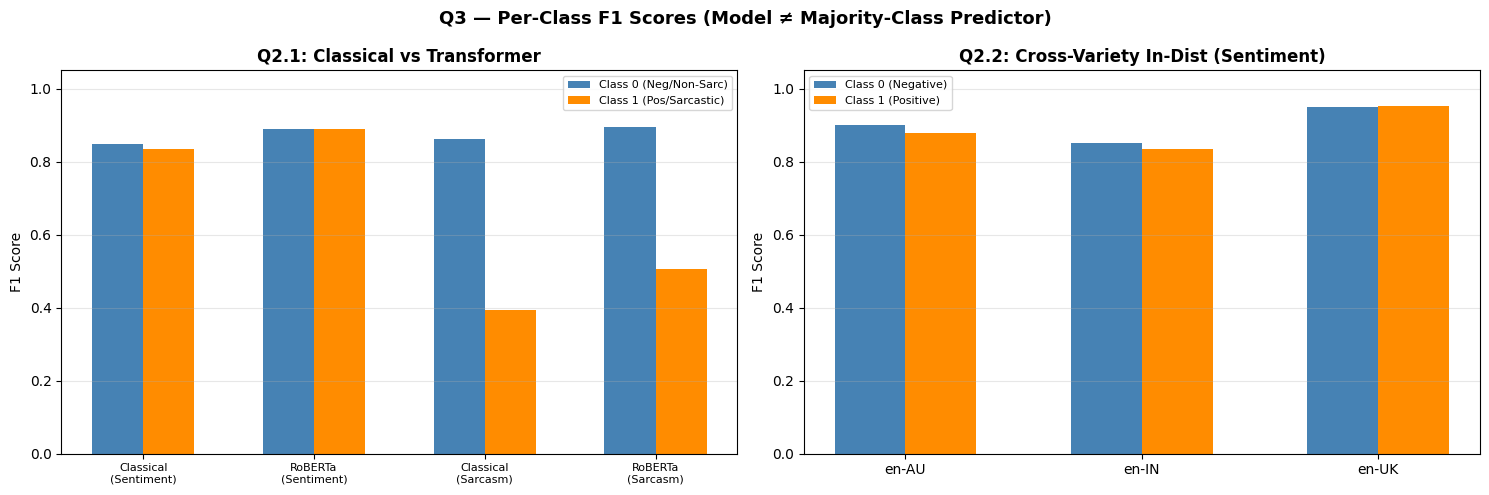

✓ Per-class F1 chart saved to q3_per_class_f1_q2_1_q2_2.png
✓ Q3 evaluation summary saved to q3_evaluation_summary.csv


In [ ]:
# -- Q3: Per-Class F1 Bar Charts ----------------------------------------------

def _cls(rpt, c):
    """Get per-class dict from report, handling str, int, and float label keys."""
    for key in [str(c), c, str(float(c)), str(int(c))]:
        if key in rpt:
            return rpt[key]
    raise KeyError(f"Class {c} not found in report keys: {list(rpt.keys())}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Q3 - Per-Class F1 Scores (Model ≠ Majority-Class Predictor)",
             fontsize=13, fontweight="bold")

# -- Left panel: Q2.1 - Classical vs Transformer --
ax = axes[0]
models_q21 = []
f1_class0_q21 = []
f1_class1_q21 = []

for task_name in ["Sentiment", "Sarcasm"]:
    # Best classical
    clf_name = best_classical[task_name]
    rpt_c = classical_all_results[task_name][clf_name][0]['report']
    models_q21.append(f"Classical\n({task_name})")
    f1_class0_q21.append(_cls(rpt_c, 0)['f1-score'])
    f1_class1_q21.append(_cls(rpt_c, 1)['f1-score'])

    # RoBERTa
    rpt_r = transformer_all_results[task_name][0]['report']
    models_q21.append(f"RoBERTa\n({task_name})")
    f1_class0_q21.append(_cls(rpt_r, 0)['f1-score'])
    f1_class1_q21.append(_cls(rpt_r, 1)['f1-score'])

x = np.arange(len(models_q21))
w = 0.3
ax.bar(x - w/2, f1_class0_q21, w, label="Class 0 (Neg/Non-Sarc)", color="steelblue")
ax.bar(x + w/2, f1_class1_q21, w, label="Class 1 (Pos/Sarcastic)", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(models_q21, fontsize=8)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title("Q2.1: Classical vs Transformer", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# -- Right panel: Q2.2 - Cross-Variety (in-distribution) --
ax = axes[1]
models_q22 = []
f1_class0_q22 = []
f1_class1_q22 = []

for train_v in VARIETIES:
    r = cross_variety_results[(train_v, CROSS_SEEDS[0])][train_v]
    rpt = r['report']
    models_q22.append(f"{train_v}")
    f1_class0_q22.append(_cls(rpt, 0)['f1-score'])
    f1_class1_q22.append(_cls(rpt, 1)['f1-score'])

x = np.arange(len(models_q22))
ax.bar(x - w/2, f1_class0_q22, w, label="Class 0 (Negative)", color="steelblue")
ax.bar(x + w/2, f1_class1_q22, w, label="Class 1 (Positive)", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(models_q22)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title(f"Q2.2: Cross-Variety In-Dist ({CROSS_TASK})", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("q3_per_class_f1_q2_1_q2_2.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Per-class F1 chart saved to q3_per_class_f1_q2_1_q2_2.png")

# -- Save Q3 summary to CSV --
q3_rows = []
for task_name in ["Sentiment", "Sarcasm"]:
    clf_name = best_classical[task_name]
    c = classical_all_results[task_name][clf_name][0]
    t = transformer_all_results[task_name][0]
    q3_rows.append({'setup': 'Q2.1', 'model': f'TF-IDF+{clf_name}', 'task': task_name,
                    'macro_f1': c['macro_f1'], 'precision': c['macro_precision'],
                    'recall': c['macro_recall'],
                    'f1_class0': _cls(c['report'], 0)['f1-score'],
                    'f1_class1': _cls(c['report'], 1)['f1-score']})
    q3_rows.append({'setup': 'Q2.1', 'model': 'RoBERTa-base', 'task': task_name,
                    'macro_f1': t['macro_f1'], 'precision': t['macro_precision'],
                    'recall': t['macro_recall'],
                    'f1_class0': _cls(t['report'], 0)['f1-score'],
                    'f1_class1': _cls(t['report'], 1)['f1-score']})

for train_v in VARIETIES:
    for test_v in VARIETIES:
        r_avg = cv_avg[(train_v, test_v)]
        r_det = cross_variety_results[(train_v, CROSS_SEEDS[0])][test_v]
        q3_rows.append({
            'setup': 'Q2.2', 'model': f'RoBERTa({train_v}→{test_v})',
            'task': CROSS_TASK,
            'macro_f1': r_avg['f1_mean'], 'precision': r_avg['prec_mean'],
            'recall': r_avg['rec_mean'],
            'f1_class0': _cls(r_det['report'], 0)['f1-score'],
            'f1_class1': _cls(r_det['report'], 1)['f1-score'],
        })

pd.DataFrame(q3_rows).to_csv("q3_evaluation_summary.csv", index=False)
print(" Q3 evaluation summary saved to q3_evaluation_summary.csv")

In [ ]:
# -- Zip all saved models and results, then download --------------------------
# import shutil
# from google.colab import files

# zip_name = "all_outputs"
# shutil.make_archive(zip_name, 'zip', SAVE_DIR)
# print(f" Created {zip_name}.zip from {SAVE_DIR}/")

# # List contents
# import zipfile
# with zipfile.ZipFile(f"{zip_name}.zip", 'r') as zf:
#     total_size = sum(info.file_size for info in zf.infolist())
#     print(f"  {len(zf.namelist())} files, {total_size / 1e6:.1f} MB uncompressed")

# files.download(f"{zip_name}.zip")
# print(" Download triggered")

✓ Created all_outputs.zip from ./saved_models/
  101 files, 11561.5 MB uncompressed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download triggered
